## Figures 11\-13

In [1]:
close all
clear
load clothes
prin=0;
Ntable=clothes;
% N=table2array(Ntable);
n=sum(Ntable{:,:},"all");
[I,J]=size(Ntable);


% Example of findEmpiricalEnvelope a struct
findEmp=struct;
% Generate nsimul contingency tables
findEmp.nsimul=1000;
% Under the null hypothesis of independence
findEmp.underH0=true;
% Store the nsimul contingency tables which have been simulated
findEmp.StoreSim=true;


% Detect outlying rows using a simultaneous confidence level
conflev=1-0.01/I;
RAWH0=mcdCorAna(Ntable,'plots',0,'findEmpiricalEnvelope',findEmp, ...
    'conflev',conflev,'bdp',0.5);

Total estimated time to complete MCD:  0.24 seconds 
Finding empirical bands


## Under H1

In [2]:
% Example of findEmpiricalEnvelope a struct
findEmp=struct;
% Generate nsimul contingency tables
findEmp.nsimul=1000;
% Under the null hypothesis of independence
findEmp.underH0=false;
% Store the nsimul robust distance sorted (for each row)
findEmp.StoreSim=true;


% Detect outlying rows using a simultaneous confidence level
conflev=1-0.01/I;
RAWH1=mcdCorAna(Ntable,'plots',0,'findEmpiricalEnvelope',findEmp, ...
    'conflev',conflev,'bdp',0.5);

Total estimated time to complete MCD:  0.05 seconds 
Finding empirical bands


## Figure 11 left panel: under H0 before rescaling

In [3]:
out=FSCorAna(RAWH0,'plots',1,'init',round(n*0.25),'conflev',[0.05 0.95],'resc',false);

Creating empirical confidence band for minimum (weighted) Mahalanobis distance
50  500  950   50  950


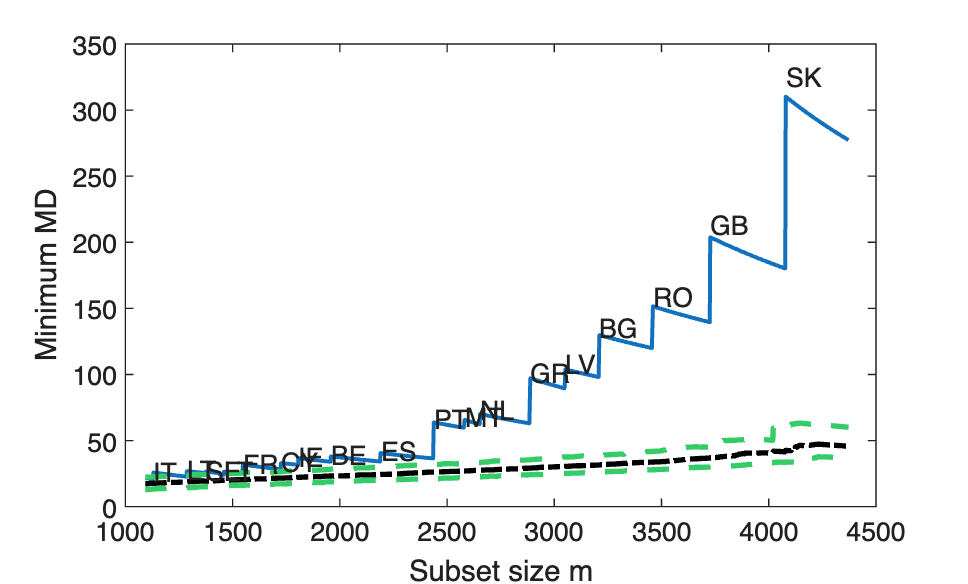

In [4]:
% Replace 'myTag' with the tag you are looking for
h = findall(0, 'Type', 'figure', 'Tag', 'pl_in');
if ~isempty(h)
    close(h)
end
ylabel('Minimum MD')
set(gcf,'Name','Figure 11 (left panel) simH0 without rescaling')

In [5]:


if prin==1
    % print to postscript
    print -depsc figs2024\ClminMDH0.eps;
end


## Figure 11 right panel: under H1 without rescaling

In [6]:
out=FSCorAna(RAWH1,'plots',1,'init',round(n*0.25),'conflev',[0.05 0.95],'resc',false);

Creating empirical confidence band for minimum (weighted) Mahalanobis distance
50  500  950   50  950


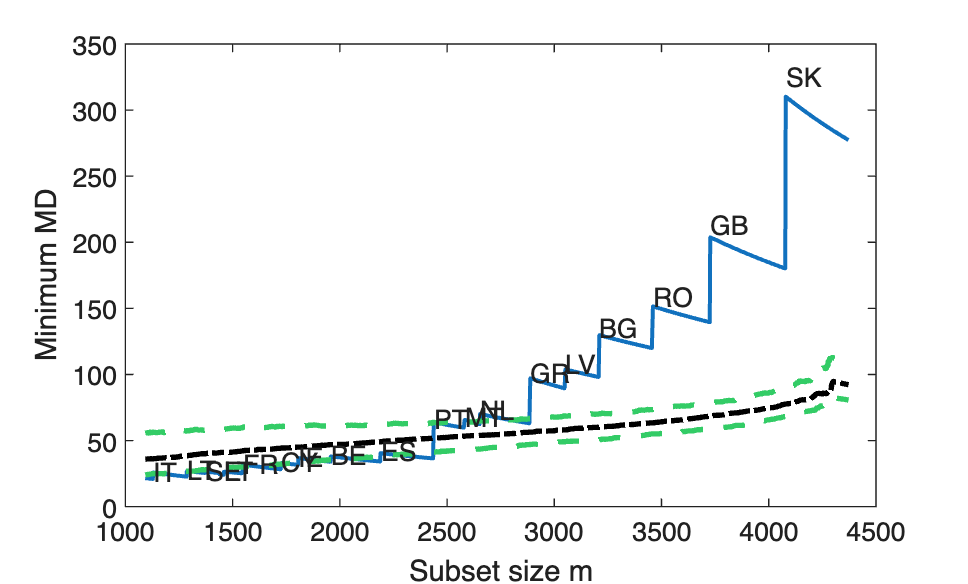

In [7]:
h = findall(0, 'Type', 'figure', 'Tag', 'pl_in');
if ~isempty(h)
    close(h)
end
ylabel('Minimum MD')
set(gcf,'Name','Figure 11 (right panel) simH1 without rescaling')


title('')

In [8]:
if prin==1
    % print to postscript
    print -depsc figs2024\ClminMDH1.eps;
end


## Figure 12: H1 with rescaling

In [9]:
out=FSCorAna(RAWH1,'plots',1,'init',round(n*0.25),'conflev',[0.05 0.95],'resc',true);

Creating empirical confidence band for minimum (weighted) Mahalanobis distance
50  500  950   50  950


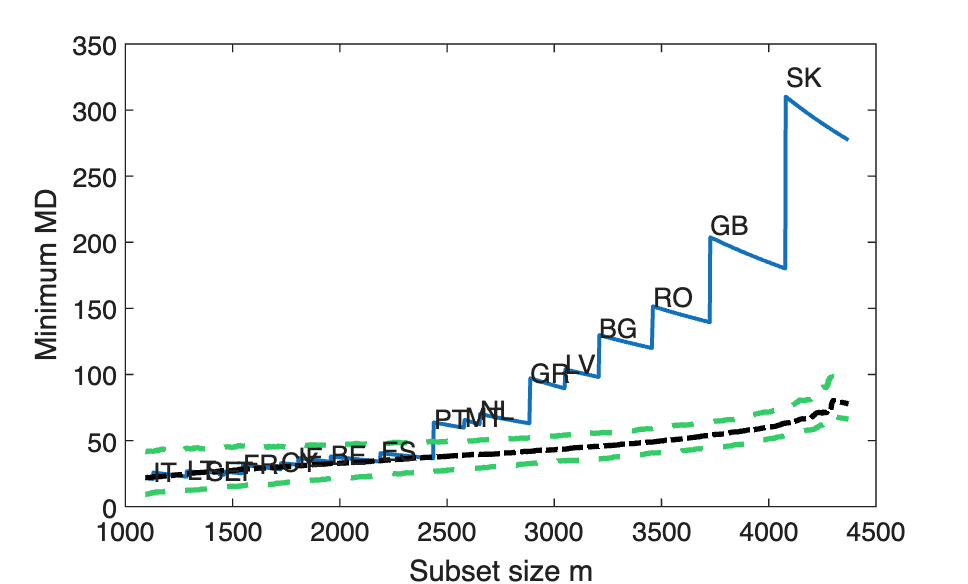

In [10]:
h = findall(0, 'Type', 'figure', 'Tag', 'pl_in');
if ~isempty(h)
    close(h)
end
ylabel('Minimum MD')
set(gcf,'Name','Figure 12 simH1 with rescaling')


title('')

In [11]:
if prin==1
    % print to postscript
    print -depsc figs2024\ClminMDH1resc.eps;
end


## Figure 13: Monitoring MD


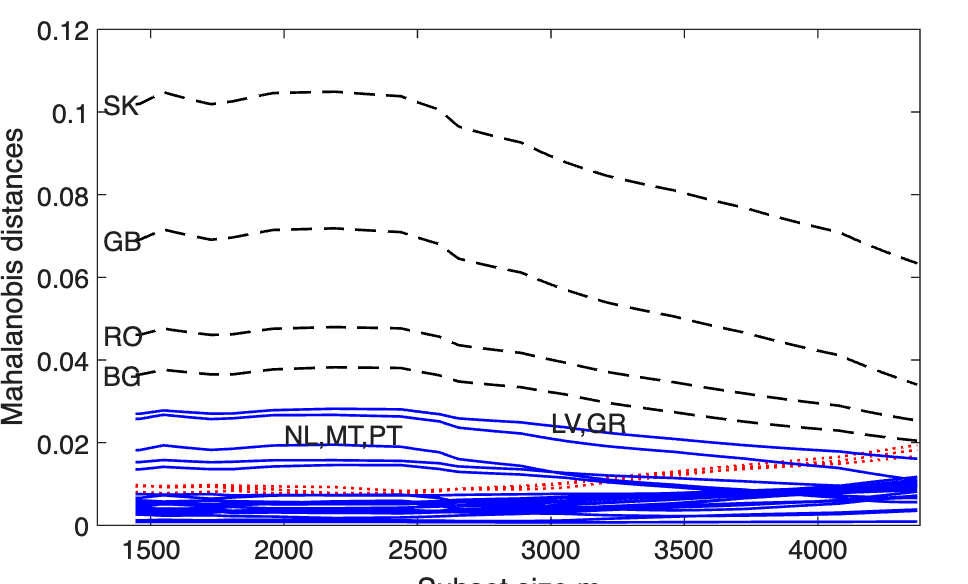

In [12]:
outEDA=FSCorAnaeda(RAWH1,'plots',0,'init',round(n*0.33),'conflev',0.99);
fground=struct;
fground.funit= [1 2 3 14 4:6  ];
fground.Color=[repmat({'k'},4,1); repmat({'r'},3,1)];  % different colors for different standard trajectories
fground.LineStyle=[repmat({'--'},3,1);repmat({':'},3,1)];
fground.flabstep='';
nam=Ntable.Properties.RowNames;
sel=[1 2 3 14];


malfwdplot(outEDA,'fground',fground,'datatooltip','')
text(repmat(1320,4,1),outEDA.MAL(sel,1),nam(sel))
xlim([1300 n+10])
text(3000,0.025,"LV,GR")
text(2000,0.022,"NL,MT,PT")
set(gcf,'Name','Figure 13  simH1. Monitoring of MD')

In [13]:


if prin==1
    % print to postscript
    print -depsc figs2024\ClmonMD.eps;
end


## Create Figure 14: monitoring of inertia

In [14]:
NwihtoutRow1=clothes;
NwihtoutRow1(1,:)=[];


I=size(NwihtoutRow1,1);
% In the mcd estimation procedure use or not bands based on alternative
% Example of findEmpiricalEnvelope a struct
findEmp=struct;
% Generate nsimul contingency tables
findEmp.nsimul=1000;
% Store the nsimul robust distance sorted (for each row)
findEmp.StoreSim=true;


conflevSim=0.99;
conflev=1-(1-conflevSim)/I;


## Figure 14: monitoring of inertia

In [15]:
% Under the null hypothesis of independence or under the alternative
findEmp.underH0=true;
% call to mcdCorAna
RAWH0=mcdCorAna(NwihtoutRow1,'plots',0,'findEmpiricalEnvelope',findEmp,'bdp',0.5,'msg',0,'conflev',conflev);

Finding empirical bands

In [16]:
outFSH0=FSCorAna(RAWH0,'plots',0,'msg',0,'StoreSim',false); % ,'conflev',conflevSim);


% Under the null hypothesis of independence or under the alternative
findEmp.underH0=false;
% call to mcdCorAna
RAWH1=mcdCorAna(NwihtoutRow1,'plots',0,'findEmpiricalEnvelope',findEmp,'bdp',0.5,'msg',0,'conflev',conflev);

Finding empirical bands

In [17]:
outFSH1=FSCorAna(RAWH1,'plots',0,'msg',0,'StoreSim',false); % ,'conflev',conflevSim);


## Monitoring of inertia under H0 and H1


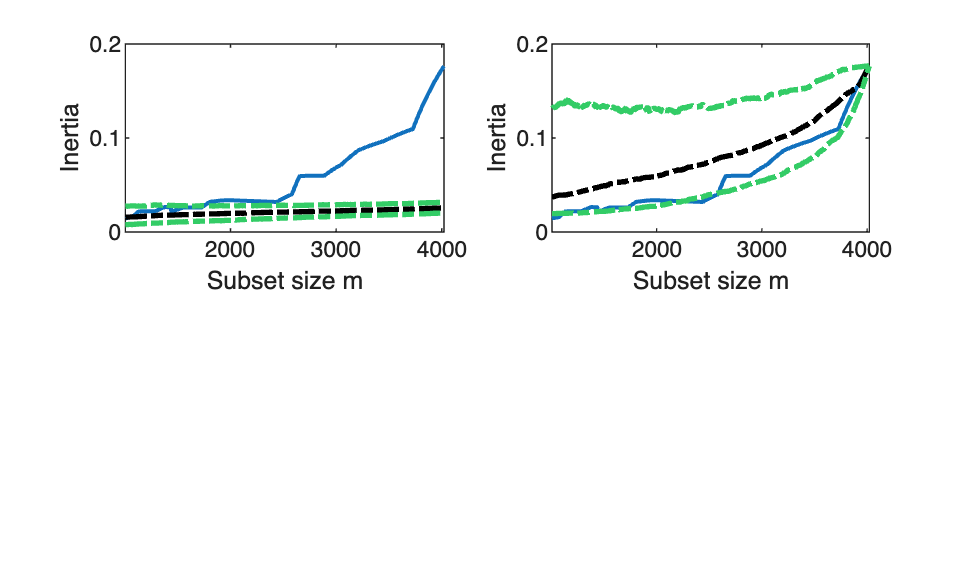

In [18]:
lwdreal=1.5;
figure
subplot(2,2,1)
plot(outFSH0.ine(:,1),outFSH0.ine(:,2),'LineWidth',lwdreal)


hold on
% include specified tag in the current plot
gine=outFSH0.ine(:,[1 3:end]);


lwdenv=2;
% Superimpose 50% envelope
line(gine(:,1),gine(:,3),'LineWidth',lwdenv,'LineStyle','-.','Color','k','tag','env');
% Superimpose alpha1% and alpha2% envelope
line(gine(:,1),gine(:,2),'LineWidth',lwdenv,'LineStyle','-.','Color',[0.2 0.8 0.4],'tag','env');
line(gine(:,1),gine(:,4),'LineWidth',lwdenv,'LineStyle','-.','Color',[0.2 0.8 0.4],'tag','env');
xlabel('Subset size m')
ylabel('Inertia')


subplot(2,2,2)
plot(outFSH1.ine(:,1),outFSH1.ine(:,2),'LineWidth',lwdreal)


hold on
% include specified tag in the current plot
gine=outFSH1.ine(:,[1 3:end]);


lwdenv=2;
% Superimpose 50% envelope
line(gine(:,1),gine(:,3),'LineWidth',lwdenv,'LineStyle','-.','Color','k','tag','env');
% Superimpose alpha1% and alpha2% envelope
line(gine(:,1),gine(:,2),'LineWidth',lwdenv,'LineStyle','-.','Color',[0.2 0.8 0.4],'tag','env');
line(gine(:,1),gine(:,4),'LineWidth',lwdenv,'LineStyle','-.','Color',[0.2 0.8 0.4],'tag','env');
xlabel('Subset size m')
ylabel('Inertia')


set(gcf,'Name','Figure 14  monitoring plots of Inertia', 'NumberTitle','off')

In [19]:


if prin==1
    print -depsc figs\I5.eps;
end